# Cognitive Parsing Engine: Project Dissection

A source-grounded walkthrough of the offline EEG/model workflow and the browser-based real-time demonstration. The project explores adaptive motor-imagery control and confidence-based assistance. This notebook distinguishes what the repository implements from what remains a simulation or an unfinished pipeline.

> **Scope:** This is a technical demonstration, not a clinical system or evidence of rehabilitation efficacy. The live web demo replays stored EEG epochs; it does not acquire a patient's live EEG.

### Interactive walkthrough

The executable lab cells later in this notebook visualize an actual EDF segment before/after filtering, run one stored epoch through ONNX inference, time the deployed model, trace decoded directions into simulated game movement, and compare the standalone PSD fatigue helper with the browser's heuristic level changes. Run the cells from top to bottom; the dataset is accessed with memory mapping and only a few epochs are read.

## Executive Summary

The project has two intended phases. **Phase 1** prepares motor-imagery examples and trains/exports a compact classifier. **Phase 2** serves an ONNX model through FastAPI and visualizes predicted intent in a browser dashboard with difficulty and assistance controls.

The browser experience demonstrates a useful concept: when inference confidence is low or a prediction disagrees with the selected target, add simulated assistance; adapt the game settings as the session changes. However, the implementation is not an end-to-end clinical loop: fatigue is not measured from the streamed signal, no headset is connected, and assistance only moves a simulated drone. The repository also does not contain a coherent checked-in 4-class training-to-ONNX-export script.

## Two-Phase Architecture

### Phase 1: Offline data preparation and model development

```text
PhysioNet EEGMMIDB EDF files
        |
        v
extract_4class.py: select runs/events, create 4-second epochs
        |
        v
data/processed/X.npy + y.npy  (expected: examples x 64 x 641, labels 0..3)
        |
        v
EEGNet training -> checkpoint -> ONNX export
        |
        v
src/saved_models/hybrid_eegnet_4class.onnx (+ external .onnx.data weights)
```

### Phase 2: FastAPI inference demo and dashboard

```text
Browser UI (templates/index.html)
        | WebSocket command (INJECT_LEFT/RIGHT/UP/DOWN)
        v
FastAPI (web_server.py) chooses a stored epoch from that target class
        | normalize -> ONNX Runtime inference -> predicted class/confidence
        v
WebSocket response: decoded class, match, confidence, waveform samples
        |
        +--> 3D brain activity visualization
        +--> EEG trace chart
        +--> simulated 3D game movement and confidence-based assistance
        +--> browser-side difficulty profile updates
```

The arrows describe the current demo behavior, not a live patient-data pathway.

## Phase 1: Offline Data and Model Pipeline

### 1. EEG source and class construction
`extract_4class.py` scans `data/eegmmidb/S*` and uses PhysioNet runs 4, 8, 12 for left/right hand imagery and runs 6, 10, 14 for both-fists/both-feet imagery. It maps annotation codes T1/T2 to four labels: 0 left hand, 1 right hand, 2 both fists (up), and 3 both feet (down).

### 2. Epoch extraction
Each event is cut from 0 to 4 seconds. Only epochs with the exact shape `(64, 641)` are retained, then data and labels are saved as `data/processed/X.npy` and `data/processed/y.npy`. Per the file, malformed/truncated run failures are silently skipped. This script does **not** apply the 8-30 Hz band-pass filter used in the older preprocessing pipeline.

### 3. Intended modeling and deployment
The Phase 1 diagram describes EEGNet training followed by ONNX export. The repository contains an ONNX model and a PyTorch checkpoint, but `src/models/deep_learning.py` currently constructs `EnhancedEEGNet(..., num_classes=2)`. It trains on its loaded labels and does not export ONNX. Since `extract_4class.py` writes label IDs through 3, that trainer and extractor are a directly compatible 4-class pipeline as checked in.


## Phase 2: Runtime Walkthrough

Launch from the project root with:

```bash
uvicorn web_server:app --reload
```

1. `web_server.py` creates an ONNX Runtime inference session from `src/saved_models/hybrid_eegnet_4class.onnx` and loads `data/processed/X.npy` and `y.npy` into memory at process startup. Startup therefore requires all three artifacts to exist and fit in RAM.
2. FastAPI serves `templates/index.html` at `/` and accepts a browser WebSocket at `/ws`. The page also loads `/static/brain.glb` and uses Three.js and Chart.js from CDNs.
3. Clicking an intent button sends an `INJECT_*` command. The backend randomly chooses a saved example whose label matches that button. This is target-conditioned sample replay, not a live EEG stream.
4. The selected epoch is normalized per channel across time, reshaped to `(1, 1, 64, 641)`, and passed to ONNX Runtime. The predicted class is converted to a direction and a confidence percentage; a set of downsampled channels is returned for charting.
5. The page updates the predicted/target labels, match and confidence indicators, session metrics, cortex highlights, EEG chart, and simulated drone. A low-confidence or mismatched result adds a target-directed assistance vector in the game.
6. Browser controls and prediction outcomes update a fatigue slider and difficulty profile. The reset command recenters the simulated drone.

## Relevant Files: What Each One Owns

| File or artifact | Role in this project |
| --- | --- |
| `web_server.py` | Runtime entry point: loads model/data, maps labels/directions, normalizes epochs, runs ONNX inference, and handles HTTP/WebSocket requests. |
| `templates/index.html` | Browser dashboard: clinical controls, intent buttons, 3D brain/game, trace chart, WebSocket client, browser-side assistance and difficulty updates. |
| `static/brain.glb` | 3D brain model loaded by the dashboard. |
| `extract_4class.py` | Current four-class EDF/event/epoch extraction path; writes `X.npy` and `y.npy`. |
| `src/models/deep_learning.py` | Enhanced EEGNet definition and a global-pretraining/subject-fine-tuning routine; currently configured for 4 classes and has ONNX export. |
| `fatigue_engine.py` | Standalone Welch PSD theta/alpha fatigue-ratio and three-level difficulty helper|
| `src/preprocessing/loader.py`, `filters.py`, `read_events.py`, `epoching.py` | Helpers for loading EDF, 8-30 Hz filtering, reading T1/T2 annotations, and making/resampling epochs in the older route. |
| `src/features/extractors.py` | CSP feature extraction and saving; used by the feature pipeline|
| `src/models/baseline.py`, `evaluate.py`, `balancing.py` | Random Forest/SVM baselines, stratified evaluation helper, and SMOTE balancing helper |
| `src/saved_models/hybrid_eegnet_4class.onnx` and `.onnx.data` | Deployed ONNX graph and external weight data expected by the runtime. |
| `src/saved_models/hybrid_eegnet_91_80.pth`, `src/models/training_results.txt` | PyTorch checkpoint and recorded historical metrics; their exact linkage to the deployed ONNX artifact is demonstrated in source. |

## Difficulty 1: Static Difficulty and Engagement

**Problem:** A fixed difficulty curve can become either frustrating or unchallenging as performance and capacity change.

**What the demo implements:** `templates/index.html` has three environment profiles. Level 1 is a guided/1D mode with slower speed, larger targets, and a higher confidence threshold (85%). Level 2 uses standard settings (speed 0.4, target scale 1.0, threshold 65%). Level 3 uses faster movement, smaller targets, and a lower threshold (40%). The profile is recalculated from the stroke-severity selection and fatigue slider; browser-side prediction outcomes also change the slider.

**What that establishes:** A working demonstration of adjustable game parameters and feedback-driven UI state. It is not evidence that an optimal or clinically validated engagement policy has been learned. The profile names and parameter choices are hand-authored; notably, Level 3 is labeled `COGNITIVE OVERLOAD`, though its settings are more demanding.

## Difficulty 2: Safety Nets and Assistance

**Problem:** A patient may need software assistance when intent decoding is uncertain or ability changes.

**What the demo implements:** When confidence is below the current threshold or the predicted class mismatches the selected target, the browser computes a simulated assist contribution and adds movement in the target direction. Higher confidence/matching predictions are presented as more direct user control. This is a confidence/mismatch-based game mechanic, not motorized physical assistance.

`fatigue_engine.py` separately calculates a Welch power-spectral-density theta/alpha ratio and maps it to difficulty levels with example thresholds. It is not imported or called by `web_server.py` or the dashboard script. Therefore this EEG fatigue estimator is currently a standalone utility, not part of the running assistance loop. The live page's fatigue value is a user-adjustable slider plus a heuristic update based on match/confidence.

**Safety boundary:** The web demo does not control a robot, orthosis, or physical actuator and must not be represented as a clinical safety net. A production system would need validated sensing, conservative fail-safe behavior, patient-specific calibration, clinician oversight, and hardware safety verification.

## Difficulty 3: Training Memory and Web Deployment

**Problem:** Large EEG training arrays can exhaust RAM, and a large model can be impractical for a browser-facing real-time service.

**What the repository demonstrates:** The runtime uses ONNX Runtime and a pre-exported ONNX model, which is a deployment-oriented format. The EEGNet architecture uses temporal and depthwise/separable convolutions, which are designed to be compact relative to many general-purpose deep networks.

**What is not demonstrated in source:** No `mmap`/memory-map usage appears in the reviewed Python code. The runtime calls `np.load` without memory mapping, loading the full processed X and y arrays into RAM. The checked-in training script also loads the full arrays and converts them to Torch tensors. There is no checked-in ONNX export routine, benchmark of model size/latency/RAM, or documented reproducible 4-class trainer-export chain. ONNX serving is a useful deployment step, but by itself it does not prove the training RAM crash was solved or that the model meets real-time clinical constraints.

## Runtime Data Contract

The web server assumes the processed arrays contain 64-channel epochs with 641 time points, and labels that can be normalized to IDs 0 through 3. Its ONNX input is built as `(batch=1, extra axis=1, channels=64, samples=641)`. The class-to-action mapping is 0 LEFT, 1 RIGHT, 2 UP, 3 DOWN.

The backend returns four selected channel traces using hard-coded channel positions `[7, 9, 11, 30]` after downsampling by four. Its source comment describes these as approximate C3/Cz/C4/Pz channels; the page plots only the first three and labels them C3/Cz/C4. These indices/labels should be verified against the exact channel ordering in the EDF files before interpreting them physiologically.

The backend response includes target label, predicted label, confidence, match flag, direction, waveform arrays, and target class. The frontend uses the target class for the assistance direction and visual cortex selection, and the predicted direction for simulated user movement.

## Status Against the Three Difficulties

| Challenge | Implemented in repository | Demonstrated by current web app | Still needed for a defensible claim |
| --- | --- | --- | --- |
| Static difficulty | Hand-authored three-level browser profiles; settings change with selected severity and fatigue value. | Yes, in a simulated game. | Validate adaptation policy and engagement/outcomes with users and clinicians. |
| Lack of safety nets | Confidence/mismatch-based assistance mechanic; standalone theta/alpha helper. | Game movement only; fatigue helper is not connected. | Live signal integration, tested fail-safe control, clinical/hardware validation. |
| Hardware bottlenecks | ONNX Runtime deployment artifact; compact EEGNet-like model. | Inference on stored examples. | Reproducible 4-class training/export, memory mapping or bounded loading if needed, and latency/RAM benchmarks. |

### Bottom line
The repository presents a strong prototype direction: adaptive task difficulty, confidence-aware software assistance, and ONNX-based inference. The current evidence supports describing it as a **simulated EEG rehabilitation dashboard prototype**. It does not yet support saying all three challenges are fully solved in a live, safe, memory-bounded clinical system.

## Run and Demonstrate

### Prerequisites
- Run from the repository root.
- Python dependencies for FastAPI, Uvicorn, NumPy, and ONNX Runtime must be installed. The browser loads Three.js/Chart.js from CDNs, so the page needs network access for those libraries.
- These files must exist: `src/saved_models/hybrid_eegnet_4class.onnx`, its external weights file if required, `data/processed/X.npy`, and `data/processed/y.npy`.

### Demonstration sequence
1. Start `uvicorn web_server:app --reload`.
2. Open `http://127.0.0.1:8000`. Confirm the WebSocket status becomes active.
3. Click each of the four target intent buttons. Observe target versus decoded class, confidence, accuracy, brain highlight, trace chart, and game movement. Remember the input epoch is sampled from the stored target class.
4. Change baseline severity and move the fatigue slider to inspect the three game profiles.
5. Observe that lower confidence or a mismatch produces an assist-vector display and target-directed simulated movement.
6. Use reset to recenter the simulated game.

This sequence demonstrates the software UI behavior, not a patient trial or real-time EEG session.

In [8]:
from pathlib import Path

# Read-only audit: report required runtime artifacts without loading EEG arrays or model weights.
project_root = Path.cwd()
required_paths = [
    Path('web_server.py'),
    Path('templates/index.html'),
    Path('static/brain.glb'),
    Path('data/processed/X.npy'),
    Path('data/processed/y.npy'),
    Path('src/saved_models/hybrid_eegnet_4class.onnx'),
    Path('src/saved_models/hybrid_eegnet_4class.onnx.data'),
]
for relative_path in required_paths:
    path = project_root / relative_path
    if path.exists():
        print(f'{relative_path}: present ({path.stat().st_size:,} bytes)')
    else:
        print(f'{relative_path}: missing')

web_server.py: present (4,076 bytes)
templates/index.html: present (27,769 bytes)
static/brain.glb: present (50,469,288 bytes)
data/processed/X.npy: present (1,558,091,648 bytes)
data/processed/y.npy: present (76,088 bytes)
src/saved_models/hybrid_eegnet_4class.onnx: present (13,566 bytes)
src/saved_models/hybrid_eegnet_4class.onnx.data: present (28,672 bytes)


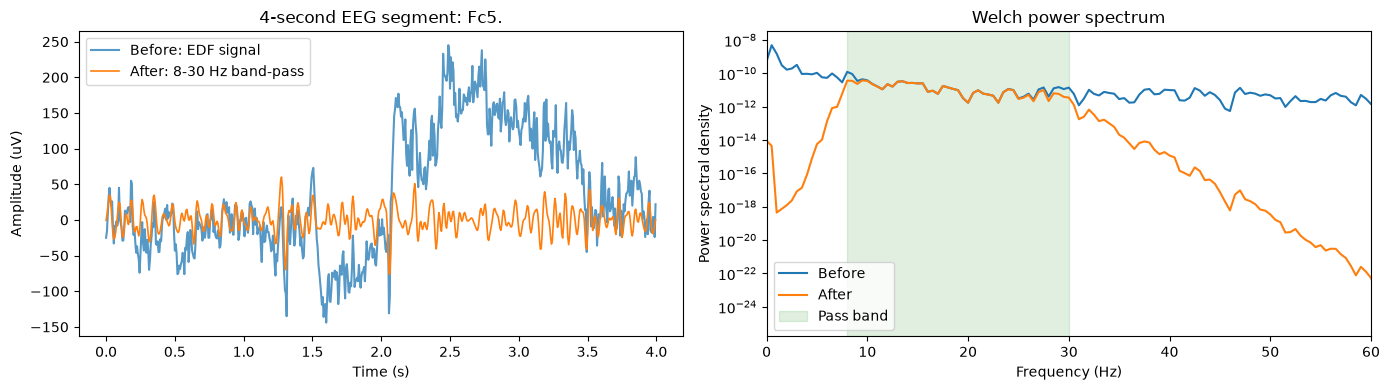

EDF: data/eegmmidb/S001/S001R04.edf | sampling rate: 160 Hz | EEG channels: 64 | segment shape: (64, 640) | start sample: 672
Interpretation: the plotted filter is the older preprocessing helper's 8-30 Hz operation, not a step currently applied by extract_4class.py.


In [9]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, welch
import mne

# Locate the project root even if the notebook kernel starts in a child folder.
search_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((path for path in search_roots if (path / "web_server.py").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the Cognitive Parsing Engine workspace.")

edf_path = PROJECT_ROOT / "data" / "eegmmidb" / "S001" / "S001R04.edf"
if not edf_path.exists():
    raise FileNotFoundError(f"Expected sample EDF is missing: {edf_path}")

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="ERROR")
eeg_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
fs = float(raw.info["sfreq"])
if len(eeg_picks) == 0 or fs <= 60:
    raise RuntimeError(f"Need EEG channels and sampling rate above 60 Hz; got {len(eeg_picks)} channels at {fs} Hz")

# Prefer an annotated motor-imagery event, just as the extraction pipeline does.
events, _ = mne.events_from_annotations(raw, event_id={"T1": 2, "T2": 3}, verbose="ERROR")
segment_length = int(round(4 * fs))
valid_events = events[events[:, 0] + segment_length <= raw.n_times] if len(events) else events
start_sample = int(valid_events[0, 0]) if len(valid_events) else 0
stop_sample = min(start_sample + segment_length, raw.n_times)
eeg_before = raw.get_data(picks=eeg_picks, start=start_sample, stop=stop_sample)
if eeg_before.shape[-1] < int(fs * 2):
    raise RuntimeError("Selected recording segment is too short to demonstrate filtering.")

# This 8-30 Hz band-pass matches src/preprocessing/filters.py.
# Note: extract_4class.py currently does not call this filter.
sos = butter(4, [8, 30], btype="bandpass", fs=fs, output="sos")
eeg_after = sosfiltfilt(sos, eeg_before, axis=-1)
frequencies_before, psd_before = welch(eeg_before, fs=fs, axis=-1, nperseg=min(int(fs * 2), eeg_before.shape[-1]))
frequencies_after, psd_after = welch(eeg_after, fs=fs, axis=-1, nperseg=min(int(fs * 2), eeg_after.shape[-1]))

channel_row = 0
channel_name = raw.ch_names[eeg_picks[channel_row]]
time_seconds = np.arange(eeg_before.shape[-1]) / fs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(time_seconds, eeg_before[channel_row] * 1e6, label="Before: EDF signal", alpha=0.75)
axes[0].plot(time_seconds, eeg_after[channel_row] * 1e6, label="After: 8-30 Hz band-pass", linewidth=1.2)
axes[0].set(title=f"4-second EEG segment: {channel_name}", xlabel="Time (s)", ylabel="Amplitude (uV)")
axes[0].legend()
axes[1].semilogy(frequencies_before, psd_before[channel_row], label="Before")
axes[1].semilogy(frequencies_after, psd_after[channel_row], label="After")
axes[1].axvspan(8, 30, alpha=0.12, color="green", label="Pass band")
axes[1].set(xlim=(0, min(60, fs / 2)), title="Welch power spectrum", xlabel="Frequency (Hz)", ylabel="Power spectral density")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"EDF: {edf_path.relative_to(PROJECT_ROOT)} | sampling rate: {fs:g} Hz | EEG channels: {len(eeg_picks)} | segment shape: {eeg_before.shape} | start sample: {start_sample}")
print("Interpretation: the plotted filter is the older preprocessing helper's 8-30 Hz operation, not a step currently applied by extract_4class.py.")

**Interpretation:** The left panel overlays one real 4-second EDF channel before and after an 8–30 Hz band-pass; the right panel shows how that channel's power spectrum changes, with the intended pass band shaded. This makes attenuation outside the target band visible. It is an illustrative filter comparison: this notebook uses a SciPy Butterworth filter, while the older project helper uses MNE's FIR filter, and `extract_4class.py` does not currently apply either filter.

## Executable Lab: Runtime Inference and Timing

The next cells follow the same small path as `web_server.py`, but use `mmap_mode="r"` so selecting one example does not pull the entire 1.56 GB `X.npy` into memory. They run a real ONNX prediction on a stored epoch, show the four returned channel traces, and time repeated CPU inference. The next cell attempts a fair eager-PyTorch comparison only if the checked-in checkpoint loads into the source EEGNet and produces the same four-class output. ONNX is an inference/deployment format; it is not a different training method, so training duration is not comparable as “with ONNX vs without ONNX.”

Target sample: index 824, class Left Hand
ONNX result: Left Hand -> LEFT | confidence 99.93% | target match: True
Input tensor: (1, 1, 64, 641) | ONNX output logits: (4,) | memmap X shape: (9495, 64, 641)


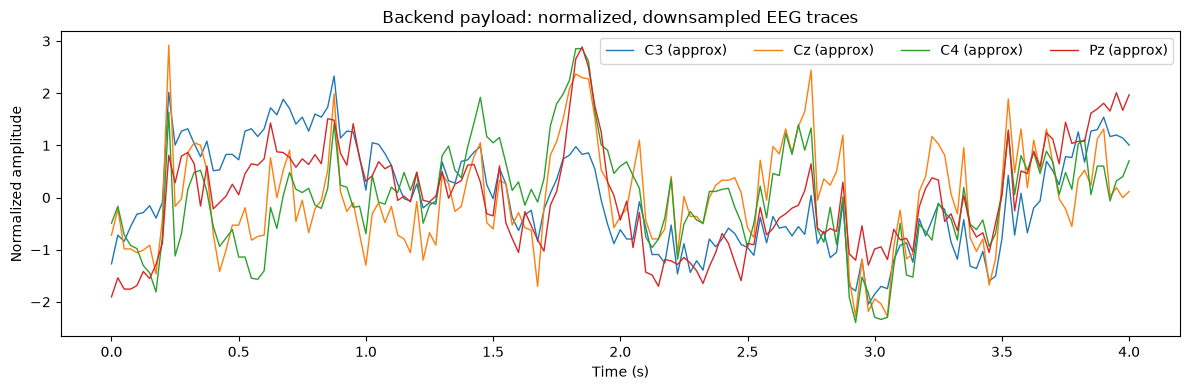

ONNX Runtime CPU inference: median 1.707 ms | p95 2.154 ms | n=50


In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

X_path = PROJECT_ROOT / "data" / "processed" / "X.npy"
y_path = PROJECT_ROOT / "data" / "processed" / "y.npy"
model_path = PROJECT_ROOT / "src" / "saved_models" / "hybrid_eegnet_4class.onnx"
X_mmap = np.load(X_path, mmap_mode="r")
y = np.asarray(np.load(y_path, mmap_mode="r"), dtype=np.int64)
if y.size and y.min() > 0:
    y = y - y.min()
if X_mmap.ndim != 3 or X_mmap.shape[1:] != (64, 641):
    raise ValueError(f"Expected examples x 64 x 641, got {X_mmap.shape}")
if not model_path.exists():
    raise FileNotFoundError(model_path)

# Single-thread CPU inference to make repeat timings easier to reproduce.
ort_options = ort.SessionOptions()
ort_options.intra_op_num_threads = 1
ort_options.inter_op_num_threads = 1
onnx_session = ort.InferenceSession(str(model_path), sess_options=ort_options, providers=["CPUExecutionProvider"])
onnx_input = onnx_session.get_inputs()[0]
onnx_output_names = [item.name for item in onnx_session.get_outputs()]

# Match web_server.py: choose an example from the requested class, normalize each
# channel over time, and add batch/model axes to produce (1, 1, 64, 641).
target_class = 0
class_indices = np.flatnonzero(y == target_class)
if class_indices.size == 0:
    raise ValueError(f"No samples found for target class {target_class}")
rng = np.random.default_rng(42)
sample_index = int(rng.choice(class_indices))
eeg_epoch = np.asarray(X_mmap[sample_index], dtype=np.float32)
epoch_mean = np.mean(eeg_epoch, axis=-1, keepdims=True)
epoch_std = np.std(eeg_epoch, axis=-1, keepdims=True) + 1e-8
normalized_epoch = (eeg_epoch - epoch_mean) / epoch_std
onnx_input_tensor = normalized_epoch[None, None, :, :].astype(np.float32, copy=False)


def onnx_predict(input_tensor=onnx_input_tensor):
    return onnx_session.run(onnx_output_names, {onnx_input.name: input_tensor})[0]

onnx_logits = np.asarray(onnx_predict()).reshape(1, -1)[0]
onnx_probabilities = np.exp(onnx_logits - np.max(onnx_logits))
onnx_probabilities /= onnx_probabilities.sum()
predicted_class = int(np.argmax(onnx_logits))
confidence_percent = float(onnx_probabilities[predicted_class] * 100)
class_labels = {0: "Left Hand", 1: "Right Hand", 2: "Both Fists (UP)", 3: "Both Feet (DOWN)"}
directions = {0: "LEFT", 1: "RIGHT", 2: "UP", 3: "DOWN"}
backend_result = {
    "sample_index": sample_index,
    "target_class": target_class,
    "prediction": predicted_class,
    "confidence": confidence_percent,
    "match": predicted_class == target_class,
    "move_cmd": directions[predicted_class],
    "logits": onnx_logits,
    "waveforms": normalized_epoch[[7, 9, 11, 30], ::4],
}
print(f"Target sample: index {sample_index}, class {class_labels[target_class]}")
print(f"ONNX result: {class_labels[predicted_class]} -> {backend_result['move_cmd']} | confidence {confidence_percent:.2f}% | target match: {backend_result['match']}")
print(f"Input tensor: {onnx_input_tensor.shape} | ONNX output logits: {onnx_logits.shape} | memmap X shape: {X_mmap.shape}")

waveform_names = ["C3 (approx)", "Cz (approx)", "C4 (approx)", "Pz (approx)"]
fig, ax = plt.subplots(figsize=(12, 4))
for waveform, name in zip(backend_result["waveforms"], waveform_names):
    ax.plot(np.arange(waveform.size) * 4 / 160, waveform, label=name, linewidth=1)
ax.set(title="Backend payload: normalized, downsampled EEG traces", xlabel="Time (s)", ylabel="Normalized amplitude")
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

# Timing is inference only: model loading, preprocessing, WebSocket and browser rendering are excluded.
for _ in range(5):
    onnx_predict()
onnx_durations_ms = []
for _ in range(50):
    tick = time.perf_counter_ns()
    onnx_predict()
    onnx_durations_ms.append((time.perf_counter_ns() - tick) / 1e6)
print(f"ONNX Runtime CPU inference: median {np.median(onnx_durations_ms):.3f} ms | p95 {np.percentile(onnx_durations_ms, 95):.3f} ms | n=50")

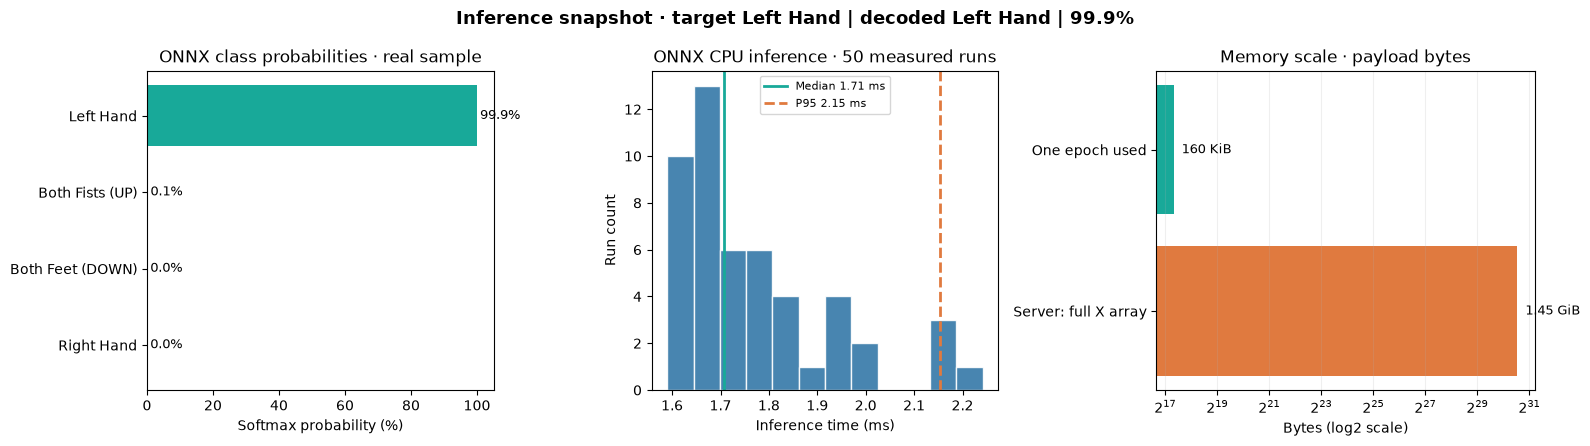

The memory bars compare the server's full X array payload with one selected epoch; they are not peak-RAM measurements.
The notebook uses mmap for demonstration. web_server.py currently loads the full arrays into memory.


In [14]:
# Results dashboard: real probabilities, measured ONNX latency, and memory-scale context.
probability_order = np.argsort(onnx_probabilities)
probability_labels = [class_labels[class_id] for class_id in probability_order]
probability_values = onnx_probabilities[probability_order] * 100
probability_colors = ["#18a999" if class_id == predicted_class else "#78909c" for class_id in probability_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1.1, 1.1, 1.2]})
axes[0].barh(probability_labels, probability_values, color=probability_colors)
axes[0].set_xlim(0, 105)
axes[0].set(title="ONNX class probabilities · real sample", xlabel="Softmax probability (%)")
for row, value in enumerate(probability_values):
    axes[0].text(value + 1, row, f"{value:.1f}%", va="center", fontsize=9)

axes[1].hist(onnx_durations_ms, bins=12, color="#3478a8", edgecolor="white", alpha=0.9)
median_latency = float(np.median(onnx_durations_ms))
p95_latency = float(np.percentile(onnx_durations_ms, 95))
axes[1].axvline(median_latency, color="#18a999", linewidth=2, label=f"Median {median_latency:.2f} ms")
axes[1].axvline(p95_latency, color="#e07a3f", linewidth=2, linestyle="--", label=f"P95 {p95_latency:.2f} ms")
axes[1].set(title="ONNX CPU inference · 50 measured runs", xlabel="Inference time (ms)", ylabel="Run count")
axes[1].legend(fontsize=8)

full_array_gib = X_mmap.nbytes / (1024 ** 3)
one_epoch_kib = eeg_epoch.nbytes / 1024
axes[2].barh(["Server: full X array", "One epoch used"], [X_mmap.nbytes, eeg_epoch.nbytes], color=["#e07a3f", "#18a999"])
axes[2].set_xscale("log", base=2)
axes[2].set(title="Memory scale · payload bytes", xlabel="Bytes (log2 scale)")
axes[2].text(X_mmap.nbytes, 0, f"  {full_array_gib:.2f} GiB", va="center", fontsize=9)
axes[2].text(eeg_epoch.nbytes, 1, f"  {one_epoch_kib:.0f} KiB", va="center", fontsize=9)
axes[2].grid(axis="x", alpha=0.2)
fig.suptitle(f"Inference snapshot · target {class_labels[target_class]} | decoded {class_labels[predicted_class]} | {confidence_percent:.1f}%", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()
print("The memory bars compare the server's full X array payload with one selected epoch; they are not peak-RAM measurements.")
print("The notebook uses mmap for demonstration. web_server.py currently loads the full arrays into memory.")

**Interpretation:** Read the panels left to right. The probability bars are the model's softmax scores for this one selected example; the highlighted bar is its predicted class, not an overall accuracy estimate. The middle histogram shows the distribution of 50 measured ONNX CPU inference calls; median and 95th-percentile lines summarize this run on this machine only. The right panel compares the complete stored `X` payload with one EEG epoch on a log scale. It illustrates why bounded/mapped access matters, but it is not a peak-memory benchmark; the current server still loads the full array.

In [11]:
# A defensible eager-PyTorch comparison requires the checkpoint to match the
# checked-in source architecture and to produce the same four logits as ONNX.
try:
    import torch
    from src.models.deep_learning import EnhancedEEGNet

    checkpoint_path = PROJECT_ROOT / "src" / "saved_models" / "hybrid_eegnet_91_80.pth"
    checkpoint_object = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    if isinstance(checkpoint_object, dict):
        state_dict = checkpoint_object.get("state_dict", checkpoint_object.get("model_state_dict", checkpoint_object))
    else:
        state_dict = checkpoint_object

    classifier_weight = state_dict.get("fc.weight") if isinstance(state_dict, dict) else None
    checkpoint_classes = int(classifier_weight.shape[0]) if classifier_weight is not None else None
    onnx_classes = int(onnx_logits.size)
    print(f"Checkpoint classifier classes: {checkpoint_classes}; ONNX output classes: {onnx_classes}")

    if checkpoint_classes != onnx_classes:
        print("No apples-to-apples PyTorch-vs-ONNX timing: this checkpoint does not have the same output class count as the deployed ONNX model.")
    else:
        eager_model = EnhancedEEGNet(channels=64, time_samples=641, num_classes=checkpoint_classes)
        eager_model.load_state_dict(state_dict, strict=True)
        eager_model.eval()
        torch.set_num_threads(1)
        torch_input = torch.from_numpy(onnx_input_tensor)
        with torch.inference_mode():
            eager_logits = eager_model(torch_input).cpu().numpy().reshape(-1)
        if eager_logits.shape != onnx_logits.shape:
            print(f"Comparison skipped: eager output {eager_logits.shape} differs from ONNX output {onnx_logits.shape}.")
        else:
            print(f"Same sample prediction: PyTorch={int(eager_logits.argmax())}, ONNX={int(onnx_logits.argmax())}")
            print(f"Logits close (atol=1e-4, rtol=1e-3): {np.allclose(eager_logits, onnx_logits, atol=1e-4, rtol=1e-3)}")
            for _ in range(5):
                with torch.inference_mode():
                    eager_model(torch_input)
            torch_durations_ms = []
            for _ in range(50):
                tick = time.perf_counter_ns()
                with torch.inference_mode():
                    eager_model(torch_input)
                torch_durations_ms.append((time.perf_counter_ns() - tick) / 1e6)
            print(f"PyTorch eager CPU inference: median {np.median(torch_durations_ms):.3f} ms | p95 {np.percentile(torch_durations_ms, 95):.3f} ms | n=50")
            print(f"ONNX Runtime CPU inference: median {np.median(onnx_durations_ms):.3f} ms | p95 {np.percentile(onnx_durations_ms, 95):.3f} ms | n=50")
except Exception as error:
    print(f"PyTorch comparison unavailable in this kernel or checkpoint: {type(error).__name__}: {error}")
    print("The ONNX measurement above is still valid as an ONNX-only inference measurement; it is not evidence of a speedup versus training or eager PyTorch.")

Checkpoint classifier classes: 2; ONNX output classes: 4
No apples-to-apples PyTorch-vs-ONNX timing: this checkpoint does not have the same output class count as the deployed ONNX model.


### Reading the timing and resource plots

The ONNX histogram is CPU inference only (50 warm runs); it excludes model startup, preprocessing, WebSocket transport, and browser rendering. The notebook attempts eager-PyTorch timing only if the source checkpoint matches the 4-class ONNX model. Here the checkpoint is 2-class, so no speedup percentage is reported. Training time is not comparable to inference time. The memory chart contrasts the full server input array with one selected epoch; it is a payload-size comparison, not measured peak RAM. The notebook uses `mmap`; `web_server.py` currently does not.

## Executable Lab: Backend Output to Game Movement

`web_server.py` returns a predicted class, confidence, target class, and direction. The browser does not consume a physical-control command: it uses the predicted direction as simulated user movement, and (when confidence is below the current threshold or the prediction mismatches the injected target) adds a second simulated movement vector toward the target. The next cell reproduces the frontend's class mapping, confidence split, axis rules, and coordinate clamps, then prints cases for all four directions.

In [12]:
import pandas as pd

CLASS_TO_DIRECTION = {0: "LEFT", 1: "RIGHT", 2: "UP", 3: "DOWN"}
CLASS_NAMES = {0: "Left Hand", 1: "Right Hand", 2: "Both Fists", 3: "Both Feet"}
DIRECTION_VECTOR = {"LEFT": (-1, 0), "RIGHT": (1, 0), "UP": (0, 1), "DOWN": (0, -1)}
LEVEL_SETTINGS = {
    1: {"name": "GUIDED THERAPY", "speed": 0.2, "hoop_scale": 1.6, "threshold": 85, "one_dimensional": True},
    2: {"name": "STANDARD NEURO-FLIGHT", "speed": 0.4, "hoop_scale": 1.0, "threshold": 65, "one_dimensional": False},
    3: {"name": "COGNITIVE OVERLOAD", "speed": 0.7, "hoop_scale": 0.6, "threshold": 40, "one_dimensional": False},
}


def browser_level(stroke, fatigue_percent):
    if stroke == "severe" or fatigue_percent > 70:
        return 1
    if stroke == "mild" or fatigue_percent < 30:
        return 3
    return 2


def game_step(target_class, predicted_class, confidence, level=2):
    """Reproduce the frontend force split and one movement step from (0, 0)."""
    profile = LEVEL_SETTINGS[level]
    threshold = profile["threshold"]
    is_match = target_class == predicted_class
    needs_assistance = confidence < threshold or not is_match
    if needs_assistance:
        user_force = confidence if is_match else confidence * 0.3
        assist_force = 100.0 - user_force
    else:
        user_force = confidence
        assist_force = 0.0

    predicted_direction = CLASS_TO_DIRECTION[predicted_class]
    target_direction = CLASS_TO_DIRECTION[target_class]
    step = 4.0
    user_vector = DIRECTION_VECTOR[predicted_direction]
    target_vector = DIRECTION_VECTOR[target_direction]
    delta_x = step * (user_vector[0] * user_force + target_vector[0] * assist_force) / 100.0
    delta_y = step * (user_vector[1] * user_force + target_vector[1] * assist_force) / 100.0
    if profile["one_dimensional"]:
        delta_y = 0.0
    delta_x = float(np.clip(delta_x, -6, 6))
    delta_y = float(np.clip(delta_y, -4, 4))
    return {
        "target": CLASS_NAMES[target_class],
        "target_action": target_direction,
        "decoded": CLASS_NAMES[predicted_class],
        "decoded_action": predicted_direction,
        "confidence_pct": round(confidence, 1),
        "threshold_pct": threshold,
        "match": is_match,
        "user_force_pct": round(user_force, 1),
        "assist_force_pct": round(assist_force, 1),
        "drone_delta_x": round(delta_x, 3),
        "drone_delta_y": round(delta_y, 3),
    }

print("Class IDs returned by the backend and consumed by the game:")
class_map_frame = pd.DataFrame([{"class_id": class_id, "label": CLASS_NAMES[class_id], "game_action": CLASS_TO_DIRECTION[class_id]} for class_id in range(4)])
print(class_map_frame.to_string(index=False))

# The HTML initializes its fatigue slider at 20 and immediately calls updateClinicalState.
initial_fatigue = 20
initial_level = browser_level("moderate", initial_fatigue)
print(f"\nHTML defaults: severity=moderate, fatigue={initial_fatigue}% -> Level {initial_level} ({LEVEL_SETTINGS[initial_level]['name']}), confidence threshold={LEVEL_SETTINGS[initial_level]['threshold']}%")
print("Note: this is Level 3 because the JavaScript treats fatigue <30 as Level 3, despite the initial HTML label saying Level 2.")

scenarios = [
    ("matched/high confidence", 0, 0, 90.0),
    ("matched/low confidence", 1, 1, 25.0),
    ("mismatch/high confidence", 2, 0, 80.0),
    ("mismatch/low confidence", 3, 1, 35.0),
]
scenario_rows = [{"case": title, **game_step(target, predicted, confidence, level=2)} for title, target, predicted, confidence in scenarios]
print("\nLevel 2 movement examples (coordinates are one simulated game step from the origin):")
print(pd.DataFrame(scenario_rows).to_string(index=False))

observed_step = game_step(backend_result["target_class"], backend_result["prediction"], backend_result["confidence"], level=initial_level)
print("\nMovement using the actual ONNX response from the prior cell:")
print(pd.Series(observed_step).to_string())

Class IDs returned by the backend and consumed by the game:
 class_id      label game_action
        0  Left Hand        LEFT
        1 Right Hand       RIGHT
        2 Both Fists          UP
        3  Both Feet        DOWN

HTML defaults: severity=moderate, fatigue=20% -> Level 3 (COGNITIVE OVERLOAD), confidence threshold=40%
Note: this is Level 3 because the JavaScript treats fatigue <30 as Level 3, despite the initial HTML label saying Level 2.

Level 2 movement examples (coordinates are one simulated game step from the origin):
                    case     target target_action    decoded decoded_action  confidence_pct  threshold_pct  match  user_force_pct  assist_force_pct  drone_delta_x  drone_delta_y
 matched/high confidence  Left Hand          LEFT  Left Hand           LEFT            90.0             65   True            90.0               0.0          -3.60           0.00
  matched/low confidence Right Hand         RIGHT Right Hand          RIGHT            25.0             6

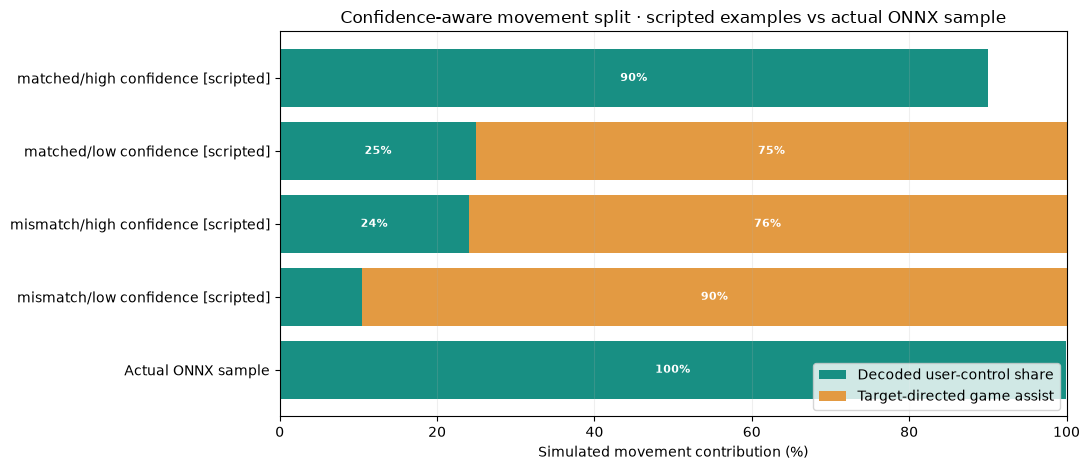

Scripted rows illustrate the browser rule; only the final row comes from the measured ONNX response. All movement is simulated in the browser game.


In [15]:
# Scripted mechanism examples plus the actual ONNX sample, clearly distinguished.
force_rows = [{"label": row["case"] + " [scripted]", **row} for row in scenario_rows]
force_rows.append({
    "label": "Actual ONNX sample",
    **observed_step,
})
force_labels = [row["label"] for row in force_rows]
user_forces = np.array([row["user_force_pct"] for row in force_rows], dtype=float)
assist_forces = np.array([row["assist_force_pct"] for row in force_rows], dtype=float)
positions = np.arange(len(force_rows))

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.barh(positions, user_forces, color="#188f83", label="Decoded user-control share")
ax.barh(positions, assist_forces, left=user_forces, color="#e39a42", label="Target-directed game assist")
ax.set_yticks(positions, force_labels)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Simulated movement contribution (%)")
ax.set_title("Confidence-aware movement split · scripted examples vs actual ONNX sample")
ax.legend(loc="lower right")
for index, (user_force, assist_force) in enumerate(zip(user_forces, assist_forces)):
    if user_force > 12:
        ax.text(user_force / 2, index, f"{user_force:.0f}%", ha="center", va="center", color="white", fontsize=8, fontweight="bold")
    if assist_force > 12:
        ax.text(user_force + assist_force / 2, index, f"{assist_force:.0f}%", ha="center", va="center", color="white", fontsize=8, fontweight="bold")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()
print("Scripted rows illustrate the browser rule; only the final row comes from the measured ONNX response. All movement is simulated in the browser game.")

**Interpretation:** Each horizontal bar totals 100% and splits one simulated game movement into the decoded user's contribution and the target-directed assistance contribution. Scripted rows show how the rule behaves for matched/mismatched and high/low-confidence cases; the final row uses the actual ONNX sample from the preceding cell. A large orange share means the game compensates more for uncertain/mismatched decoding. This is a visualization of the browser's arithmetic only, not physical assistance.

## Executable Lab: Fatigue Signal and Adaptive Levels

This section deliberately shows **two distinct mechanisms**. `fatigue_engine.py` computes a theta/alpha power ratio from EEG and returns a difficulty level, but the web app does not call it. The browser instead maintains a 0-100 slider using each prediction's match/confidence result, then maps severity/fatigue to game settings. The following cell measures the standalone PSD helper on the same real EDF segment and then replays four real stored-example ONNX predictions through the browser's fatigue update rules.

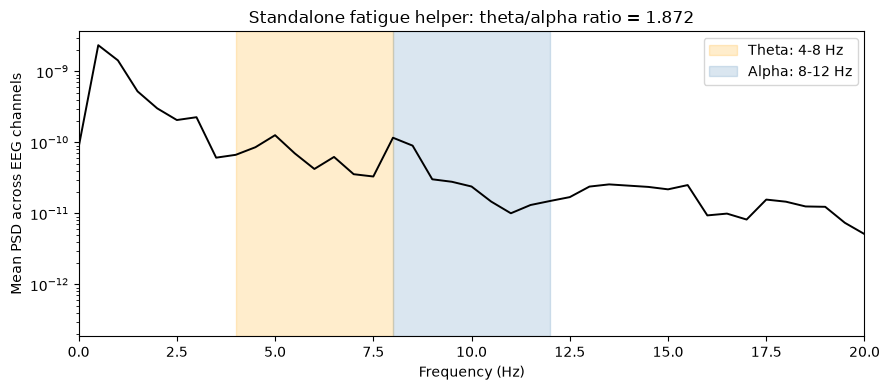

fatigue_engine.py result: ratio=1.8715, difficulty=1 (moderate baseline)
This PSD result is not sent to the browser in the current web app.

Browser heuristic replay using one actual ONNX example per target class:
 trial     target    decoded  confidence_pct  threshold_before_pct  match  fatigue_before_pct  fatigue_after_pct  level_before  level_after   new_game_profile
     1  Left Hand  Left Hand            92.1                    40   True                20.0               19.5             3            3 COGNITIVE OVERLOAD
     2 Right Hand Right Hand            68.4                    40   True                19.5               19.0             3            3 COGNITIVE OVERLOAD
     3 Both Fists Both Fists            41.6                    40   True                19.0               18.5             3            3 COGNITIVE OVERLOAD
     4  Both Feet  Both Feet            98.1                    40   True                18.5               18.0             3            3 COGNITIVE 

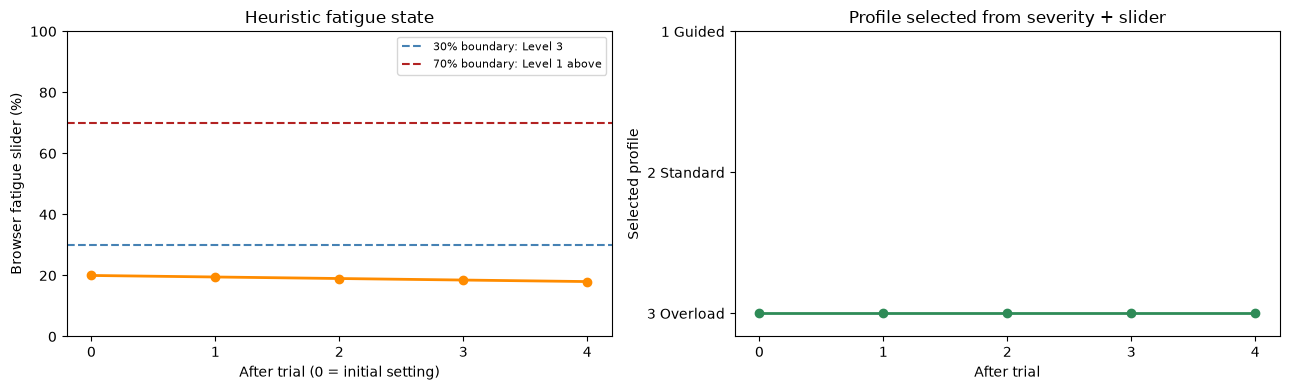


Moderate-severity slider boundaries:
 fatigue_pct  level               profile  assist_threshold_pct
           0      3    COGNITIVE OVERLOAD                    40
          20      3    COGNITIVE OVERLOAD                    40
          29      3    COGNITIVE OVERLOAD                    40
          30      2 STANDARD NEURO-FLIGHT                    65
          50      2 STANDARD NEURO-FLIGHT                    65
          70      2 STANDARD NEURO-FLIGHT                    65
          71      1        GUIDED THERAPY                    85
         100      1        GUIDED THERAPY                    85


In [13]:
import sys
from scipy.signal import welch
sys.path.insert(0, str(PROJECT_ROOT))
from fatigue_engine import FatigueMonitor

# Run the repository's standalone PSD-based helper on the real 64-channel EDF segment.
fatigue_monitor = FatigueMonitor(fs=int(round(fs)))
raw_theta_alpha = fatigue_monitor.calculate_fatigue_ratio(eeg_before)
standalone_difficulty = fatigue_monitor.get_difficulty_level(raw_theta_alpha, baseline_stroke_level="moderate")
frequency_axis, psd_channels = welch(eeg_before, fs=fs, nperseg=int(fs * 2), axis=-1)
mean_psd = psd_channels.mean(axis=0)
theta_mask = (frequency_axis >= 4) & (frequency_axis <= 8)
alpha_mask = (frequency_axis >= 8) & (frequency_axis <= 12)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(frequency_axis, mean_psd, color="black", linewidth=1.4)
ax.axvspan(4, 8, color="orange", alpha=0.2, label="Theta: 4-8 Hz")
ax.axvspan(8, 12, color="steelblue", alpha=0.2, label="Alpha: 8-12 Hz")
ax.set(xlim=(0, 20), title=f"Standalone fatigue helper: theta/alpha ratio = {raw_theta_alpha:.3f}", xlabel="Frequency (Hz)", ylabel="Mean PSD across EEG channels")
ax.legend()
plt.tight_layout()
plt.show()
print(f"fatigue_engine.py result: ratio={raw_theta_alpha:.4f}, difficulty={standalone_difficulty} (moderate baseline)")
print("This PSD result is not sent to the browser in the current web app.")

# Reuse one real, deterministic stored epoch from each class and follow the dashboard's
# exact slider update: failure/low confidence +3.5, otherwise -1.0, then +0.5 drift.
trial_observations = []
for requested_class in range(4):
    candidates = np.flatnonzero(y == requested_class)
    if candidates.size == 0:
        raise ValueError(f"No stored samples for class {requested_class}")
    idx = int(candidates[0])
    epoch = np.asarray(X_mmap[idx], dtype=np.float32)
    epoch = (epoch - epoch.mean(axis=-1, keepdims=True)) / (epoch.std(axis=-1, keepdims=True) + 1e-8)
    trial_logits = np.asarray(onnx_session.run(onnx_output_names, {onnx_input.name: epoch[None, None, :, :]})[0]).reshape(-1)
    trial_probs = np.exp(trial_logits - trial_logits.max())
    trial_probs /= trial_probs.sum()
    decoded_class = int(trial_logits.argmax())
    trial_observations.append({
        "target_class": requested_class,
        "prediction": decoded_class,
        "confidence": float(trial_probs[decoded_class] * 100),
        "match": decoded_class == requested_class,
    })

fatigue_percent = 20.0
stroke_level = "moderate"
fatigue_history = [fatigue_percent]
level_history = [browser_level(stroke_level, fatigue_percent)]
trial_rows = []
for trial_number, observation in enumerate(trial_observations, start=1):
    level_before = browser_level(stroke_level, fatigue_percent)
    threshold = LEVEL_SETTINGS[level_before]["threshold"]
    before = fatigue_percent
    if not observation["match"] or observation["confidence"] < threshold:
        fatigue_percent += 3.5
    else:
        fatigue_percent -= 1.0
    fatigue_percent = float(np.clip(fatigue_percent + 0.5, 0, 100))
    level_after = browser_level(stroke_level, fatigue_percent)
    trial_rows.append({
        "trial": trial_number,
        "target": CLASS_NAMES[observation["target_class"]],
        "decoded": CLASS_NAMES[observation["prediction"]],
        "confidence_pct": round(observation["confidence"], 1),
        "threshold_before_pct": threshold,
        "match": observation["match"],
        "fatigue_before_pct": round(before, 1),
        "fatigue_after_pct": round(fatigue_percent, 1),
        "level_before": level_before,
        "level_after": level_after,
        "new_game_profile": LEVEL_SETTINGS[level_after]["name"],
    })
    fatigue_history.append(fatigue_percent)
    level_history.append(level_after)

print("\nBrowser heuristic replay using one actual ONNX example per target class:")
print(pd.DataFrame(trial_rows).to_string(index=False))

trial_axis = np.arange(len(fatigue_history))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(trial_axis, fatigue_history, marker="o", color="darkorange", linewidth=2)
axes[0].axhline(30, linestyle="--", color="steelblue", label="30% boundary: Level 3")
axes[0].axhline(70, linestyle="--", color="firebrick", label="70% boundary: Level 1 above")
axes[0].set(xticks=trial_axis, xlabel="After trial (0 = initial setting)", ylabel="Browser fatigue slider (%)", title="Heuristic fatigue state")
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8)
axes[1].step(trial_axis, level_history, where="post", marker="o", color="seagreen", linewidth=2)
axes[1].set(xticks=trial_axis, yticks=[1, 2, 3], yticklabels=["1 Guided", "2 Standard", "3 Overload"], xlabel="After trial", ylabel="Selected profile", title="Profile selected from severity + slider")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

fatigue_grid = [0, 20, 29, 30, 50, 70, 71, 100]
print("\nModerate-severity slider boundaries:")
print(pd.DataFrame([{"fatigue_pct": value, "level": browser_level("moderate", value), "profile": LEVEL_SETTINGS[browser_level("moderate", value)]["name"], "assist_threshold_pct": LEVEL_SETTINGS[browser_level("moderate", value)]["threshold"]} for value in fatigue_grid]).to_string(index=False))

**Interpretation:** The spectrum averages power over the 64 channels of one real EDF segment; shaded 4–8 Hz and 8–12 Hz regions are the theta and alpha bands used by `FatigueMonitor`. The displayed ratio and difficulty are the standalone helper's calculation for this segment and the selected baseline. The two panels below it instead show the browser slider after four deterministic stored-example predictions: the left traces the heuristic percentage, and the right shows the corresponding profile selected from severity plus that percentage. They are different mechanisms: the PSD-derived difficulty does not drive the browser, and four replayed trials are not a patient fatigue trend.

### Illustrative level-transition scenario (scripted, not patient data)

The four real ONNX examples above happen to decode correctly and therefore do not drive the slider across levels. This next block deliberately feeds repeated low-confidence/mismatched outcomes into the browser's own update rule to make its possible transitions visible. It is a software-behavior illustration, not a measured fatigue trajectory, model result, or clinical finding.

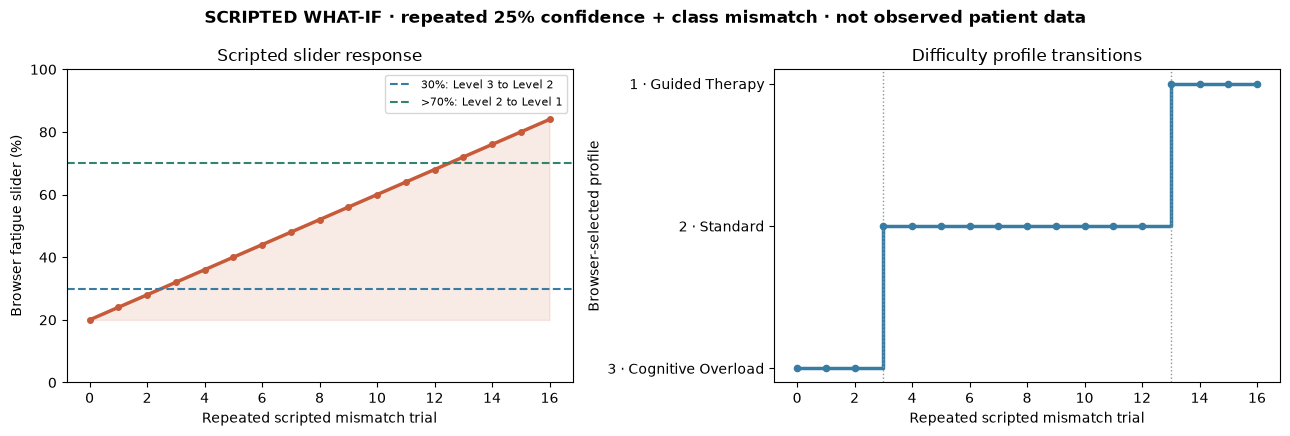

Level transitions under this deliberately repeated failure scenario:
 trial  fatigue_pct  level  threshold_pct               profile
     0         20.0      3            NaN                   NaN
     3         32.0      2           65.0 STANDARD NEURO-FLIGHT
    13         72.0      1           85.0        GUIDED THERAPY
These plotted points are generated by the dashboard rule, not recorded EEG fatigue measurements.


In [16]:
# A transparent, deterministic what-if: repeat a low-confidence mismatch at 25%.
# It makes no assertion about how often this happens in real users.
scripted_fatigue = 20.0
scripted_rows = [{"trial": 0, "fatigue_pct": scripted_fatigue, "level": browser_level("moderate", scripted_fatigue)}]
scripted_event_count = 16
for trial_number in range(1, scripted_event_count + 1):
    current_level = browser_level("moderate", scripted_fatigue)
    current_threshold = LEVEL_SETTINGS[current_level]["threshold"]
    scripted_match = False
    scripted_confidence = 25.0
    if not scripted_match or scripted_confidence < current_threshold:
        scripted_fatigue += 3.5
    else:
        scripted_fatigue -= 1.0
    scripted_fatigue = float(np.clip(scripted_fatigue + 0.5, 0, 100))
    next_level = browser_level("moderate", scripted_fatigue)
    scripted_rows.append({
        "trial": trial_number,
        "fatigue_pct": scripted_fatigue,
        "level": next_level,
        "threshold_pct": LEVEL_SETTINGS[next_level]["threshold"],
        "profile": LEVEL_SETTINGS[next_level]["name"],
    })

scripted_frame = pd.DataFrame(scripted_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(scripted_frame["trial"], scripted_frame["fatigue_pct"], color="#c75b39", linewidth=2.5, marker="o", markersize=4)
axes[0].axhline(30, color="#387ca3", linestyle="--", label="30%: Level 3 to Level 2")
axes[0].axhline(70, color="#32836f", linestyle="--", label=">70%: Level 2 to Level 1")
axes[0].fill_between(scripted_frame["trial"], scripted_frame["fatigue_pct"], 20, color="#c75b39", alpha=0.12)
axes[0].set(title="Scripted slider response", xlabel="Repeated scripted mismatch trial", ylabel="Browser fatigue slider (%)", ylim=(0, 100))
axes[0].legend(fontsize=8)

axes[1].step(scripted_frame["trial"], scripted_frame["level"], where="post", color="#387ca3", linewidth=2.5)
axes[1].scatter(scripted_frame["trial"], scripted_frame["level"], color="#387ca3", s=20, zorder=3)
axes[1].set(yticks=[1, 2, 3], yticklabels=["1 · Guided Therapy", "2 · Standard", "3 · Cognitive Overload"], xlabel="Repeated scripted mismatch trial", ylabel="Browser-selected profile", title="Difficulty profile transitions")
axes[1].invert_yaxis()
for transition_trial in scripted_frame.loc[scripted_frame["level"].ne(scripted_frame["level"].shift()), "trial"].iloc[1:]:
    axes[1].axvline(transition_trial, color="#89959d", linestyle=":", linewidth=1)
fig.suptitle("SCRIPTED WHAT-IF · repeated 25% confidence + class mismatch · not observed patient data", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

transition_rows = scripted_frame.loc[scripted_frame["level"].ne(scripted_frame["level"].shift()), ["trial", "fatigue_pct", "level", "threshold_pct", "profile"]]
print("Level transitions under this deliberately repeated failure scenario:")
print(transition_rows.to_string(index=False))
print("These plotted points are generated by the dashboard rule, not recorded EEG fatigue measurements.")

**Interpretation:** This is a deliberately scripted stress case: every trial is forced to be a 25% confidence mismatch, so the browser's fatigue slider rises by its implemented rule. The left panel shows that generated slider path; the right panel marks when the threshold rules switch profiles (Level 3 to 2 at 30%, then Level 2 to 1 above 70%). It demonstrates how the UI logic responds, not how a real user's fatigue changes or how often these events occur.